# Conditional StyleGAN3 for BEC Soliton Image Generation

This notebook builds a **conditional GAN with StyleGAN3** to generate realistic Bose–Einstein condensate (BEC) images with control over:

- Class: no soliton (`label=0`), single soliton (`label=1`), multi-excitation (`label=2`)
- Soliton position (`excitation_position`) when valid
- Optional quality/reliability weighting (`excitation_quality`, `3-agree`)

It excludes mislabeled/bad data (`label` in `{8, 9}`), prepares a StyleGAN3-compatible conditional dataset, and provides training + validation tooling.

In [1]:
from __future__ import annotations

import csv
import json
import math
import random
import re
import shutil
import subprocess
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
from PIL import Image

# Optional plotting
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [19]:
# --- Paths and high-level config ---
cwd = Path.cwd().resolve()

# Deterministic root resolution:
# use the nearest ancestor named 'In-this-deep-together', then step one level up.
anchor = None
for parent in [cwd, *cwd.parents]:
    if parent.name == "In-this-deep-together":
        anchor = parent
        break

if anchor is None:
    raise FileNotFoundError(
        f"Could not locate ancestor folder 'In-this-deep-together' from cwd={cwd}"
    )

ROOT = anchor.parent

DATA_ROOT = ROOT / "In-this-deep-together" / "data"
CSV_PATH = DATA_ROOT / "data_info" / "data_roster.csv"
NPY_ROOT = DATA_ROOT / "data_files"

# Output directories
WORK_ROOT = ROOT / "In-this-deep-together" / "Improve" / "Simulate new data" / "stylegan3_conditional"
EXPORT_ROOT = WORK_ROOT / "exported_dataset"
STYLEGAN3_ROOT = WORK_ROOT / "stylegan3"  # clone target for NVIDIA repo
RUNS_ROOT = WORK_ROOT / "training-runs"
GEN_ROOT = WORK_ROOT / "generated"

# Data behavior
APPLY_LOG_SCALING = False
ENABLE_FLIPS = True  # horizontal, vertical, both
IMAGE_WIDTH = 164
IMAGE_HEIGHT = 132
PAD_TO_SQUARE = True
TARGET_RESOLUTION = 164

# Conditioning options
USE_EXCITATION_QUALITY_IN_C = True
MASK_SOLITON_X_WITH_VALID = True

# Training options
BATCH_SIZE = 16
GAMMA = 8.0
KIMG = 4000
AUG = "ada"
CFG = "stylegan3-t"

for p in [WORK_ROOT, EXPORT_ROOT, RUNS_ROOT, GEN_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("CWD:", cwd)
print("ANCHOR:", anchor)
print("ROOT:", ROOT)
print("CSV:", CSV_PATH)
print("NPY ROOT:", NPY_ROOT)
print("WORK ROOT:", WORK_ROOT)
print("TARGET_RESOLUTION:", TARGET_RESOLUTION)

CWD: C:\Users\Leden\Documents\Bradley\DLiP\In-this-deep-together\Improve\Simulate new data
ANCHOR: C:\Users\Leden\Documents\Bradley\DLiP\In-this-deep-together
ROOT: C:\Users\Leden\Documents\Bradley\DLiP
CSV: C:\Users\Leden\Documents\Bradley\DLiP\In-this-deep-together\data\data_info\data_roster.csv
NPY ROOT: C:\Users\Leden\Documents\Bradley\DLiP\In-this-deep-together\data\data_files
WORK ROOT: C:\Users\Leden\Documents\Bradley\DLiP\In-this-deep-together\Improve\Simulate new data\stylegan3_conditional
TARGET_RESOLUTION: 164


In [3]:
@dataclass
class Sample:
    npy_path: Path
    label: int
    agree3: float
    excitation_position: float
    excitation_quality: float


def _safe_float(v: object, default: float = 0.0) -> float:
    if v is None:
        return default
    s = str(v).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return default

    # Supports plain values and bracketed values like "[0.73]"
    m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", s)
    if m is None:
        return default
    try:
        return float(m.group(0))
    except ValueError:
        return default


def _resolve_label(row: Dict[str, str]) -> Optional[int]:
    label_keys = [k for k in row.keys() if k.startswith("label_v")]
    if not label_keys:
        return None
    # Prefer highest version suffix if multiple label_v* columns exist
    label_keys = sorted(label_keys)
    val = row[label_keys[-1]]
    try:
        return int(float(val))
    except Exception:
        return None


def _resolve_npy_path(row: Dict[str, str], npy_root: Path) -> Optional[Path]:
    candidates = []
    for key in ["filename", "file_name", "path", "filepath", "file", "npy", ""]:
        if key in row and str(row[key]).strip():
            candidates.append(str(row[key]).strip())

    for c in candidates:
        p = Path(c)

        # Case 1: absolute local path already valid
        if p.suffix == ".npy" and p.is_absolute() and p.exists():
            return p

        # Case 2: relative-like path under npy_root
        if p.suffix == ".npy":
            local = npy_root / p
            if local.exists():
                return local

        # Case 3: CSV uses repo-style paths like /data/data_files/class-1/file.npy
        s = c.replace("\\", "/")
        marker = "/data/data_files/"
        if marker in s:
            rel = s.split(marker, 1)[1].lstrip("/")
            mapped = npy_root / rel
            if mapped.exists():
                return mapped

    # Fallback: derive from class folder + explicit filename field if available
    label = _resolve_label(row)
    if label is None:
        return None
    name_fields = ["basename", "stem", "id"]
    for k in name_fields:
        if k in row and str(row[k]).strip():
            stem = str(row[k]).strip()
            p = npy_root / f"class-{label}" / f"{stem}.npy"
            if p.exists():
                return p

    return None


def load_filtered_metadata(csv_path: Path, npy_root: Path) -> List[Sample]:
    samples: List[Sample] = []
    with csv_path.open("r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            label = _resolve_label(row)
            if label is None:
                continue
            if label in {8, 9}:
                continue
            if label not in {0, 1, 2}:
                continue

            npy_path = _resolve_npy_path(row, npy_root)
            if npy_path is None or not npy_path.exists():
                continue

            sample = Sample(
                npy_path=npy_path,
                label=label,
                agree3=_safe_float(row.get("3-agree", 1.0), 1.0),
                excitation_position=_safe_float(row.get("excitation_position", 0.0), 0.0),
                excitation_quality=_safe_float(row.get("excitation_quality", 1.0), 1.0),
            )
            samples.append(sample)
    return samples


samples = load_filtered_metadata(CSV_PATH, NPY_ROOT)
print(f"Loaded filtered samples: {len(samples)}")
print("Class counts:")
for cls in [0, 1, 2]:
    print(f"  class {cls}:", sum(1 for s in samples if s.label == cls))

Loaded filtered samples: 5378
Class counts:
  class 0: 1130
  class 1: 3212
  class 2: 1036


In [20]:
def preprocess_image(arr: np.ndarray, apply_log_scaling: bool = False) -> np.ndarray:
    x = arr.astype(np.float32)

    # Ensure 2D grayscale
    if x.ndim > 2:
        x = np.squeeze(x)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D grayscale image, got shape {x.shape}")

    if apply_log_scaling:
        # Robust log scaling for optical-density-like maps
        x = np.log1p(np.clip(x - np.min(x), a_min=0.0, a_max=None))

    x_min, x_max = float(np.min(x)), float(np.max(x))
    if x_max > x_min:
        x = 2.0 * (x - x_min) / (x_max - x_min) - 1.0
    else:
        x = np.zeros_like(x, dtype=np.float32)

    return np.clip(x, -1.0, 1.0)


def pad_or_crop_to_square(x: np.ndarray, target: int) -> np.ndarray:
    h, w = x.shape

    # Center-crop if larger than target
    if h > target:
        top = (h - target) // 2
        x = x[top:top + target, :]
        h = target
    if w > target:
        left = (w - target) // 2
        x = x[:, left:left + target]
        w = target

    # Symmetric zero-padding if smaller than target
    pad_h = max(0, target - h)
    pad_w = max(0, target - w)
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    if pad_h > 0 or pad_w > 0:
        x = np.pad(x, ((pad_top, pad_bottom), (pad_left, pad_right)), mode="constant", constant_values=-1.0)

    return x


def to_uint8_from_minus1_1(x: np.ndarray) -> np.ndarray:
    y = ((x + 1.0) * 127.5).round().clip(0, 255).astype(np.uint8)
    return y


def normalize_soliton_x(raw_pos: float, width: int) -> float:
    # Maps pixel-like x in [0, width-1] to [-1, 1]
    if width <= 1:
        return 0.0
    return float(np.clip(2.0 * (raw_pos / (width - 1.0)) - 1.0, -1.0, 1.0))


def build_condition_vector(sample: Sample, width: int) -> np.ndarray:
    is_0 = 1.0 if sample.label == 0 else 0.0
    is_1 = 1.0 if sample.label == 1 else 0.0
    is_multi = 1.0 if sample.label == 2 else 0.0

    soliton_valid = is_1
    soliton_x = normalize_soliton_x(sample.excitation_position, width) if sample.label == 1 else 0.0
    if MASK_SOLITON_X_WITH_VALID:
        soliton_x *= soliton_valid

    excitation_quality = sample.excitation_quality if sample.label == 1 else 0.0
    if not USE_EXCITATION_QUALITY_IN_C:
        excitation_quality = 0.0

    c = np.array([is_0, is_1, is_multi, soliton_x, soliton_valid, excitation_quality], dtype=np.float32)
    return c

In [21]:
def augment_variants(x: np.ndarray, enabled: bool = True) -> List[Tuple[str, np.ndarray]]:
    variants = [("orig", x)]
    if not enabled:
        return variants

    variants.extend([
        ("hflip", np.flip(x, axis=1)),
        ("vflip", np.flip(x, axis=0)),
        ("hvflip", np.flip(np.flip(x, axis=0), axis=1)),
    ])
    return variants


def maybe_transform_soliton_x_for_flip(soliton_x: float, variant_name: str, soliton_valid: float) -> float:
    # Horizontal flip mirrors x, vertical flip does not affect x
    if soliton_valid < 0.5:
        return 0.0
    if variant_name in {"hflip", "hvflip"}:
        return -soliton_x
    return soliton_x


def load_npy_image(npy_path: Path) -> np.ndarray:
    raw = np.load(npy_path, allow_pickle=True)

    # Common case: plain numeric 2D array
    if isinstance(raw, np.ndarray) and raw.dtype != object:
        return raw

    # Object-wrapped formats (e.g., dict with cloud_data/masked_data)
    payload = raw.item() if isinstance(raw, np.ndarray) and raw.shape == () else raw
    if isinstance(payload, dict):
        for key in ["cloud_data", "masked_data", "image", "img", "data"]:
            if key in payload and isinstance(payload[key], np.ndarray):
                return payload[key]
        # Fallback: first ndarray value in dict
        for value in payload.values():
            if isinstance(value, np.ndarray):
                return value

    if isinstance(payload, np.ndarray):
        return payload

    raise ValueError(f"Unsupported npy payload format in {npy_path}")


def export_stylegan3_conditional_dataset(samples: Sequence[Sample], export_root: Path) -> Dict[str, int]:
    if export_root.exists():
        shutil.rmtree(export_root)
    export_root.mkdir(parents=True, exist_ok=True)

    images_dir = export_root / "images"
    images_dir.mkdir(parents=True, exist_ok=True)

    labels: Dict[str, List[float]] = {}
    weights: Dict[str, float] = {}

    idx = 0
    skipped_bad_shape = 0
    skipped_bad_load = 0
    for sample in samples:
        try:
            arr = load_npy_image(sample.npy_path)
        except Exception:
            skipped_bad_load += 1
            continue

        x = preprocess_image(arr, apply_log_scaling=APPLY_LOG_SCALING)

        if x.shape != (IMAGE_HEIGHT, IMAGE_WIDTH):
            skipped_bad_shape += 1
            continue

        if PAD_TO_SQUARE:
            x = pad_or_crop_to_square(x, TARGET_RESOLUTION)

        if x.shape[0] != x.shape[1]:
            raise ValueError(f"StyleGAN3 requires square images, got {x.shape}")

        c_base = build_condition_vector(sample, width=IMAGE_WIDTH)

        for vname, xv in augment_variants(x, enabled=ENABLE_FLIPS):
            c = c_base.copy()
            c[3] = maybe_transform_soliton_x_for_flip(c[3], vname, c[4])

            image_name = f"{idx:07d}.png"
            image_path = images_dir / image_name
            image_path.parent.mkdir(parents=True, exist_ok=True)
            Image.fromarray(to_uint8_from_minus1_1(xv), mode="L").save(image_path)

            rel_key = f"images/{image_name}"
            labels[rel_key] = [float(v) for v in c]

            # Optional sample weighting for reliability / quality
            sample_weight = 1.0
            sample_weight *= float(np.clip(sample.agree3, 0.0, 1.0))
            if sample.label == 1:
                sample_weight *= float(np.clip(sample.excitation_quality, 0.0, 1.0))
            weights[rel_key] = sample_weight

            idx += 1

    dataset_json = {"labels": labels}
    with (export_root / "dataset.json").open("w", encoding="utf-8") as f:
        json.dump(dataset_json, f)

    with (export_root / "sample_weights.json").open("w", encoding="utf-8") as f:
        json.dump(weights, f)

    stats = {
        "num_exported": idx,
        "skipped_bad_shape": skipped_bad_shape,
        "skipped_bad_load": skipped_bad_load,
        "cond_dim": 6,
        "export_resolution": [int(x.shape[1]), int(x.shape[0])] if idx > 0 else None,
    }
    with (export_root / "stats.json").open("w", encoding="utf-8") as f:
        json.dump(stats, f, indent=2)

    return stats


stats = export_stylegan3_conditional_dataset(samples, EXPORT_ROOT)
stats

{'num_exported': 21512,
 'skipped_bad_shape': 0,
 'skipped_bad_load': 0,
 'cond_dim': 6,
 'export_resolution': [164, 164]}

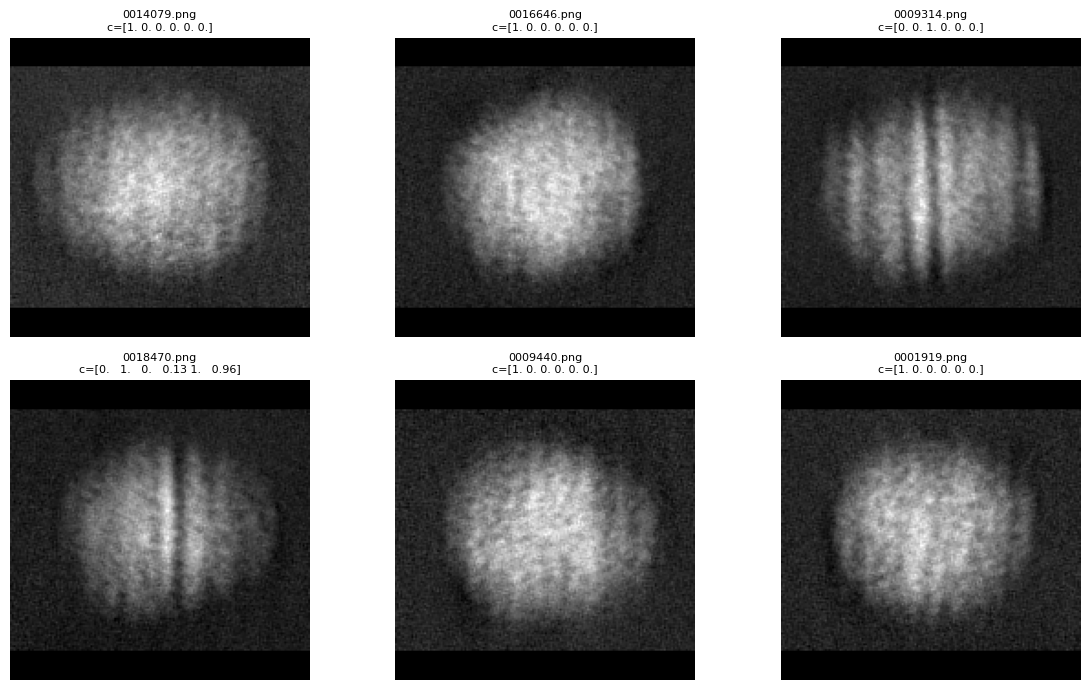

In [22]:
# Quick sanity preview of random exported items
rng = np.random.default_rng(SEED)
all_pngs = sorted((EXPORT_ROOT / "images").glob("*.png"))
preview = rng.choice(all_pngs, size=min(6, len(all_pngs)), replace=False) if all_pngs else []

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()
for ax, p in zip(axes, preview):
    im = np.array(Image.open(p))
    rel = f"images/{p.name}"
    with (EXPORT_ROOT / "dataset.json").open("r", encoding="utf-8") as f:
        cdict = json.load(f)["labels"]
    c = cdict[rel]
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{p.name}\nc={np.round(c, 2)}", fontsize=8)
    ax.axis("off")

for i in range(len(preview), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## StyleGAN3 setup (official NVIDIA implementation)

This section clones StyleGAN3 (if needed) and constructs a conditional training command:

- `--cond=1` enables conditioning from `dataset.json`
- `--cfg=stylegan3-t` uses translation-equivariant architecture
- `--aug=ada` enables adaptive augmentation
- `--batch` and `--gamma` are set for BEC image scale and stability

> If you have already cloned StyleGAN3 elsewhere, set `STYLEGAN3_ROOT` to that path.

In [7]:
# Clone StyleGAN3 if not present
if not STYLEGAN3_ROOT.exists():
    cmd = [
        "git", "clone", "https://github.com/NVlabs/stylegan3.git", str(STYLEGAN3_ROOT)
    ]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)
else:
    print("StyleGAN3 repo already exists:", STYLEGAN3_ROOT)

# Install dependencies (run once)
# You may need a CUDA-enabled PyTorch install matching your GPU driver.
requirements_path = STYLEGAN3_ROOT / "requirements.txt"
print("Install with:")
print(f"pip install -r \"{requirements_path}\"")

Running: git clone https://github.com/NVlabs/stylegan3.git C:\Users\Leden\Documents\Bradley\DLiP\In-this-deep-together\Improve\Simulate new data\stylegan3_conditional\stylegan3
Install with:
pip install -r "C:\Users\Leden\Documents\Bradley\DLiP\In-this-deep-together\Improve\Simulate new data\stylegan3_conditional\stylegan3\requirements.txt"


In [18]:
# Build a training command for conditional StyleGAN3
import torch

train_py = STYLEGAN3_ROOT / "train.py"
if not train_py.exists():
    raise FileNotFoundError(f"Could not find train.py at {train_py}")

cuda_available = torch.cuda.is_available()
num_gpus = torch.cuda.device_count() if cuda_available else 0

# Actual local launch uses current machine capabilities.
local_gpus = max(1, num_gpus) if cuda_available else 0

# Portable command for a CUDA machine (at least 1 GPU).
portable_gpu_count = 1

common_args = [
    f"--outdir={RUNS_ROOT}",
    f"--data={EXPORT_ROOT}",
    "--cond=1",
    f"--cfg={CFG}",
    f"--batch={BATCH_SIZE}",
    f"--gamma={GAMMA}",
    f"--kimg={KIMG}",
    f"--aug={AUG}",
    "--mirror=0",  # we already included explicit flips
    "--workers=4",
    "--snap=10",
]

train_cmd_local = [sys.executable, str(train_py), f"--gpus={local_gpus}", *common_args]
train_cmd_portable = [sys.executable, str(train_py), f"--gpus={portable_gpu_count}", *common_args]

print(f"CUDA available: {cuda_available}")
print(f"Detected GPU count: {num_gpus}")

if cuda_available:
    print("Local training command:")
    print(" \n  ".join(train_cmd_local))
else:
    print("No CUDA GPU detected on this PC, so local training is disabled.")
    print("Run this command on a CUDA-enabled PC:")
    print(" \n  ".join(train_cmd_portable))

CUDA available: False
Detected GPU count: 0
No CUDA GPU detected on this PC, so local training is disabled.
Run this command on a CUDA-enabled PC:
c:\Users\Leden\anaconda3\envs\SDenv\python.exe 
  C:\Users\Leden\Documents\Bradley\DLiP\In-this-deep-together\Improve\Simulate new data\stylegan3_conditional\stylegan3\train.py 
  --gpus=1 
  --outdir=C:\Users\Leden\Documents\Bradley\DLiP\In-this-deep-together\Improve\Simulate new data\stylegan3_conditional\training-runs 
  --data=C:\Users\Leden\Documents\Bradley\DLiP\In-this-deep-together\Improve\Simulate new data\stylegan3_conditional\exported_dataset 
  --cond=1 
  --cfg=stylegan3-t 
  --batch=16 
  --gamma=8.0 
  --kimg=4000 
  --aug=ada 
  --mirror=0 
  --workers=4 
  --snap=10


In [17]:
# Launch switch
RUN_TRAINING = False

if RUN_TRAINING:
    if not cuda_available:
        raise RuntimeError(
            "No CUDA GPU detected on this machine. Use the printed portable command on a CUDA PC."
        )
    print("Launching training on local CUDA GPU(s)...")
    subprocess.run(train_cmd_local, cwd=STYLEGAN3_ROOT, check=True)
else:
    print("Local launch skipped (RUN_TRAINING=False).")
    if not cuda_available:
        print("Use the CUDA-machine command printed in Cell 10 when you move to a GPU PC.")

Local launch skipped (RUN_TRAINING=False).
Use the CUDA-machine command printed in Cell 10 when you move to a GPU PC.


## Controlled validation utilities

After training, these cells evaluate:

1. **Label control**: fixed latent seed + varying class bits
2. **Spatial control**: fixed latent seed + varying `soliton_x` (for class 1)
3. **Diversity**: fixed condition + varying seeds

They load the trained StyleGAN3 generator directly and pass the full conditioning vector `c`.

In [10]:
def latest_network_pkl(runs_root: Path) -> Path:
    run_dirs = sorted([p for p in runs_root.glob("*") if p.is_dir()])
    if not run_dirs:
        raise FileNotFoundError("No training run directories found.")
    latest = run_dirs[-1]
    pkl_files = sorted(latest.glob("network-snapshot-*.pkl"))
    if not pkl_files:
        final_pkl = latest / "network-final.pkl"
        if final_pkl.exists():
            return final_pkl
        raise FileNotFoundError(f"No network snapshot found in {latest}")
    return pkl_files[-1]


def cond_vector(
    label: int,
    soliton_x: float = 0.0,
    excitation_quality: float = 1.0,
) -> List[float]:
    is_0 = 1.0 if label == 0 else 0.0
    is_1 = 1.0 if label == 1 else 0.0
    is_multi = 1.0 if label == 2 else 0.0
    soliton_valid = is_1
    sx = float(np.clip(soliton_x, -1.0, 1.0)) if label == 1 else 0.0
    if MASK_SOLITON_X_WITH_VALID:
        sx *= soliton_valid
    eq = float(np.clip(excitation_quality, 0.0, 1.0)) if label == 1 else 0.0
    return [is_0, is_1, is_multi, sx, soliton_valid, eq]


def _load_stylegan3_generator(network_pkl: Path):
    import torch

    if str(STYLEGAN3_ROOT) not in sys.path:
        sys.path.insert(0, str(STYLEGAN3_ROOT))

    import dnnlib  # type: ignore
    import legacy  # type: ignore

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    with dnnlib.util.open_url(str(network_pkl)) as f:
        G = legacy.load_network_pkl(f)["G_ema"].to(device)
    return G, device, torch


def run_gen_images(network_pkl: Path, outdir: Path, seeds: Sequence[int], cond: Sequence[float]):
    outdir.mkdir(parents=True, exist_ok=True)
    G, device, torch = _load_stylegan3_generator(network_pkl)

    c_vec = np.asarray(cond, dtype=np.float32)
    if c_vec.shape[0] != G.c_dim:
        raise ValueError(f"Condition dim mismatch: got {c_vec.shape[0]}, model expects {G.c_dim}")

    c = torch.from_numpy(c_vec[None, :]).to(device)

    for seed in seeds:
        rng = np.random.RandomState(seed)
        z = torch.from_numpy(rng.randn(1, G.z_dim).astype(np.float32)).to(device)

        img = G(z, c, noise_mode="const")
        img = (img * 127.5 + 128).clamp(0, 255).to(torch.uint8)

        # NCHW -> HWC
        img_np = img[0].permute(1, 2, 0).cpu().numpy()
        if img_np.shape[2] == 1:
            pil = Image.fromarray(img_np[:, :, 0], mode="L")
        else:
            pil = Image.fromarray(img_np, mode="RGB")

        pil.save(outdir / f"seed{seed:04d}.png")

    print(f"Saved {len(seeds)} images to {outdir}")

In [11]:
# 1) Label control: fix z (seed), vary class bits
RUN_LABEL_CONTROL = False

if RUN_LABEL_CONTROL:
    net = latest_network_pkl(RUNS_ROOT)
    seed = 123
    base_out = GEN_ROOT / "label_control"

    run_gen_images(net, base_out / "class0", [seed], cond_vector(label=0))
    run_gen_images(net, base_out / "class1", [seed], cond_vector(label=1, soliton_x=0.0, excitation_quality=1.0))
    run_gen_images(net, base_out / "class2", [seed], cond_vector(label=2))
else:
    print("Set RUN_LABEL_CONTROL=True after training.")

Set RUN_LABEL_CONTROL=True after training.


In [12]:
# 2) Spatial control: fix z and label=1, vary soliton_x
RUN_SPATIAL_CONTROL = False

if RUN_SPATIAL_CONTROL:
    net = latest_network_pkl(RUNS_ROOT)
    seed = 321
    base_out = GEN_ROOT / "spatial_control"

    for sx in [-0.8, -0.4, 0.0, 0.4, 0.8]:
        outdir = base_out / f"sx_{sx:+.1f}".replace("+", "pos").replace("-", "neg")
        run_gen_images(net, outdir, [seed], cond_vector(label=1, soliton_x=sx, excitation_quality=1.0))
else:
    print("Set RUN_SPATIAL_CONTROL=True after training.")

Set RUN_SPATIAL_CONTROL=True after training.


In [13]:
# 3) Diversity: fix condition, vary z
RUN_DIVERSITY_CHECK = False

if RUN_DIVERSITY_CHECK:
    net = latest_network_pkl(RUNS_ROOT)
    outdir = GEN_ROOT / "diversity"
    seeds = list(range(100, 116))

    # Example: class 1 at centered soliton
    c = cond_vector(label=1, soliton_x=0.0, excitation_quality=1.0)
    run_gen_images(net, outdir, seeds, c)
else:
    print("Set RUN_DIVERSITY_CHECK=True after training.")

Set RUN_DIVERSITY_CHECK=True after training.


## Optional enhancements implemented as hooks

- **Reliability/quality weighting**: exported in `sample_weights.json` for custom weighted sampler or weighted loss.
- **Gaussian spatial hint channel**: can be added during preprocessing by extending each image to 2 channels (density + hint) and modifying StyleGAN3 input pipeline.
- **Frequency/edge preservation loss**: can be integrated via custom discriminator auxiliary loss in StyleGAN3 training loop.

### Notes on weighted loss

StyleGAN3's stock trainer does not directly consume per-sample weights. To use:

1. Add a weighted sampler in `training/dataset.py` consumer path, or
2. Multiply discriminator/gen losses by sample weights after batch retrieval.

A simple proxy already included in this notebook is to encode `excitation_quality` in `c` and let conditioning learn quality-dependent realism.